In [1]:
import pandas as pd

data = pd.read_csv("student_performance.csv")

print(data.head())
print("-"*50)
print(data.info())
print("-"*50)
print(data.describe())

   student_id  weekly_self_study_hours  attendance_percentage  \
0           1                     18.5                   95.6   
1           2                     14.0                   80.0   
2           3                     19.5                   86.3   
3           4                     25.7                   70.2   
4           5                     13.4                   81.9   

   class_participation  total_score grade  
0                  3.8         97.9     A  
1                  2.5         83.9     B  
2                  5.3        100.0     A  
3                  7.0        100.0     A  
4                  6.9         92.0     A  
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hou

In [2]:
#check missing values
print(data.isnull().sum())

student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64


In [3]:
#if data is missing
data=data.dropna()

In [4]:
#if categorical columns exists
#converting categorical data into numerical form
data = pd.get_dummies(data)

In [9]:
#split features & target
X = data[[
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation"
]]
y = data["total_score"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
#we cannot be able to use SVM because it cannot handle large data and even linearSvm can also not handle it
# from sklearn.svm import LinearSVR

In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1),
    # "SVM": LinearSVR()
}

In [14]:
#used to select 10000 random rows from dataset if dataset is long
data = data.sample(n=10000, random_state=42)
# #to speed up SVM
# models["SVM"] = SVR(kernel = "linear")

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"Model: {name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)
    print("-"*50)

Model: Linear Regression
MAE: 7.161333476729989
RMSE: 8.996400873369835
R2: 0.6600425865640975
--------------------------------------------------
Model: Decision Tree
MAE: 8.36398783683165
RMSE: 11.621277994777161
R2: 0.43272362331384295
--------------------------------------------------
Model: Random Forest
MAE: 6.1018986204708225
RMSE: 8.200137008762647
R2: 0.7175580927440859
--------------------------------------------------


In [16]:
best_model = LinearRegression()
best_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


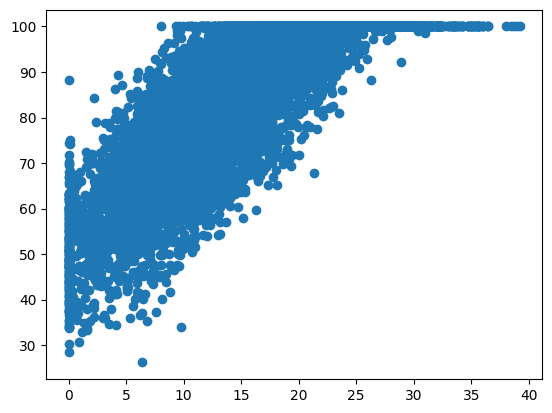

In [17]:
import matplotlib.pyplot as plt

plt.scatter(data["weekly_self_study_hours"],data["total_score"])
plt.show()

In [18]:
import pickle

with open("model.pkl","wb") as f:
    pickle.dump(best_model, f)